In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns=None
import warnings

In [2]:
train = pd.read_csv('/kaggle/input/learning-agency-lab-automated-essay-scoring-2/train.csv')
train.head()

,essay_id,full_text,score
0,000d118,Many people have car where they live. The thin...,3
1,000fe60,I am a scientist at NASA that is discussing th...,3
2,001ab80,People always wish they had the same technolog...,4
3,001bdc0,"We all heard about Venus, the planet without a...",4
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3


In [3]:
test = pd.read_csv('/kaggle/input/learning-agency-lab-automated-essay-scoring-2/test.csv')
test.head()

,essay_id,full_text
0,000d118,Many people have car where they live. The thin...
1,000fe60,I am a scientist at NASA that is discussing th...
2,001ab80,People always wish they had the same technolog...


In [4]:
combined = pd.concat([train,test])
combined.head()

,essay_id,full_text,score
0,000d118,Many people have car where they live. The thin...,3.0
1,000fe60,I am a scientist at NASA that is discussing th...,3.0
2,001ab80,People always wish they had the same technolog...,4.0
3,001bdc0,"We all heard about Venus, the planet without a...",4.0
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3.0


In [5]:
combined.info

<bound method DataFrame.info of       essay_id                                          full_text  score
0      000d118  Many people have car where they live. The thin...    3.0
1      000fe60  I am a scientist at NASA that is discussing th...    3.0
2      001ab80  People always wish they had the same technolog...    4.0
3      001bdc0  We all heard about Venus, the planet without a...    4.0
4      002ba53  Dear, State Senator\n\nThis is a letter to arg...    3.0
...        ...                                                ...    ...
17305  fffb49b  In "The Challenge of Exporing Venus," the auth...    1.0
17306  fffed3e  Venus is worthy place to study but dangerous. ...    2.0
0      000d118  Many people have car where they live. The thin...    NaN
1      000fe60  I am a scientist at NASA that is discussing th...    NaN
2      001ab80  People always wish they had the same technolog...    NaN

[17310 rows x 3 columns]>

In [6]:
combined.dtypes

essay_id      object
full_text     object
score        float64
dtype: object

In [7]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
score,17307.0,2.948402,1.044899,1.0,2.0,3.0,4.0,6.0


In [8]:
combined.columns

Index(['essay_id', 'full_text', 'score'], dtype='object')

In [9]:

combined.shape

(17310, 3)

In [10]:
cat_cols = combined.select_dtypes(include='object')

In [11]:
for i in cat_cols:
    print(i)
    (combined[i].value_counts())
    print(''*50)

essay_id

full_text



In [12]:
num_cols = combined.select_dtypes(include='number')

In [13]:
for i in num_cols:
    print(i)
    (combined[i].value_counts())
    print(''*50)

score



<Axes: >

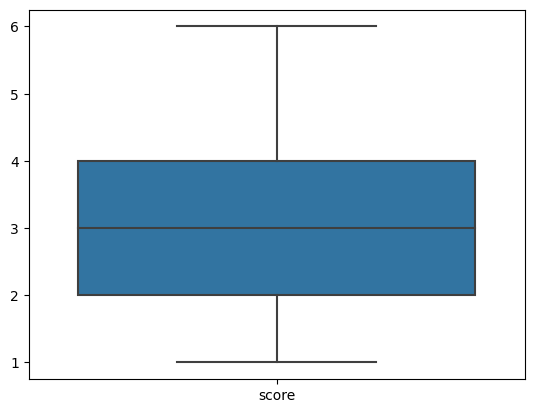

In [14]:
sns.boxplot(combined)

<Axes: >

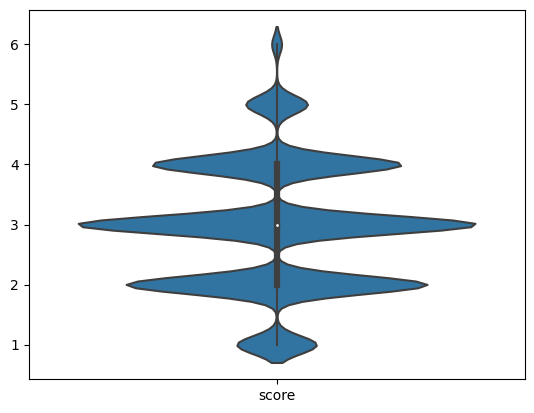

In [15]:
sns.violinplot(combined)

<Axes: >

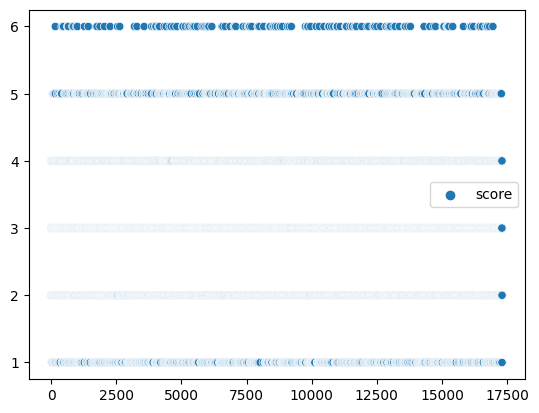

In [16]:
sns.scatterplot(combined)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


<Axes: ylabel='Density'>

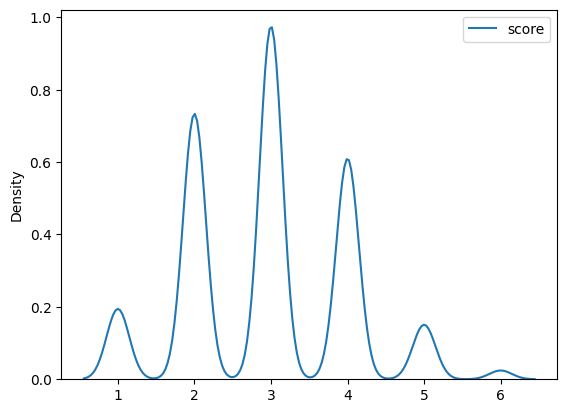

In [17]:
sns.kdeplot(combined)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: >

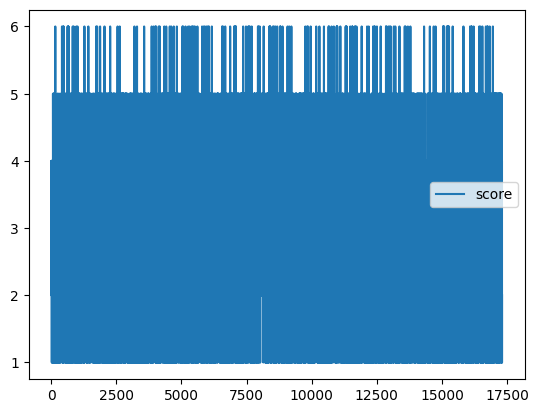

In [18]:
sns.lineplot(combined)

<Axes: ylabel='count'>

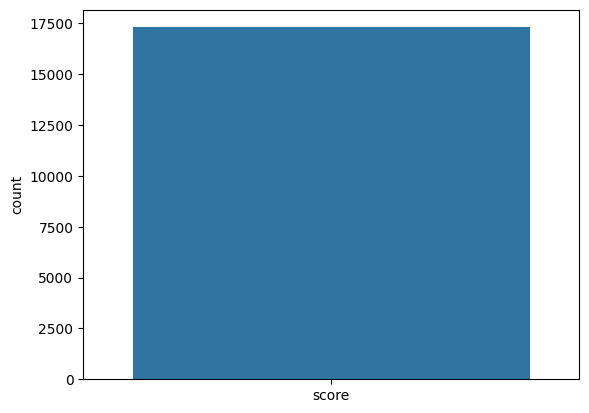

In [19]:
sns.countplot(combined)

<Axes: >

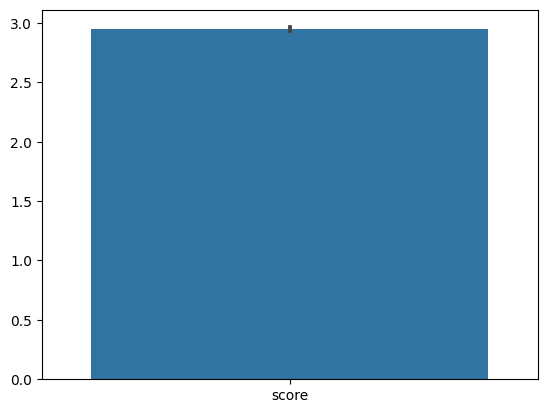

In [20]:
sns.barplot(combined)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


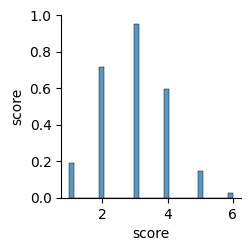

In [21]:
sns.pairplot(combined)

In [24]:
combined.head()

,essay_id,full_text,score
0,000d118,Many people have car where they live. The thin...,3.0
1,000fe60,I am a scientist at NASA that is discussing th...,3.0
2,001ab80,People always wish they had the same technolog...,4.0
3,001bdc0,"We all heard about Venus, the planet without a...",4.0
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3.0


In [25]:
x = combined[['essay_id']]

In [26]:
y = [['essay_id	']]

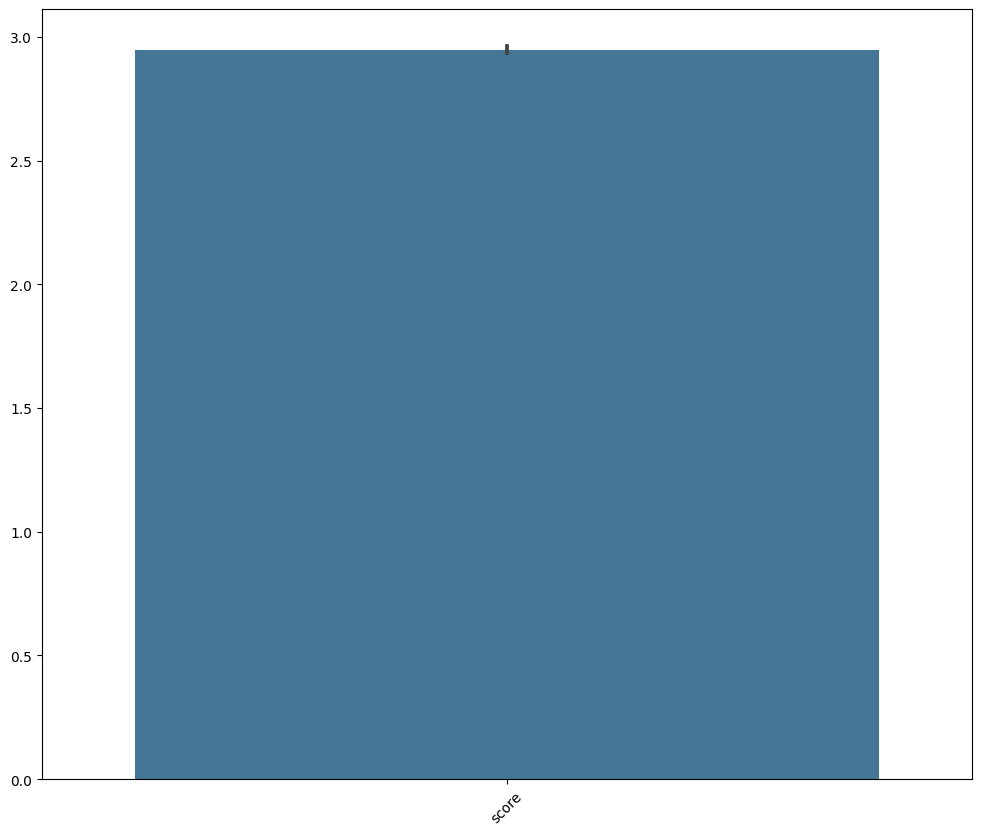

In [32]:
plt.figure(figsize=(12,10))
sns.barplot(data=combined,palette='mako');
plt.xticks(rotation=45);
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


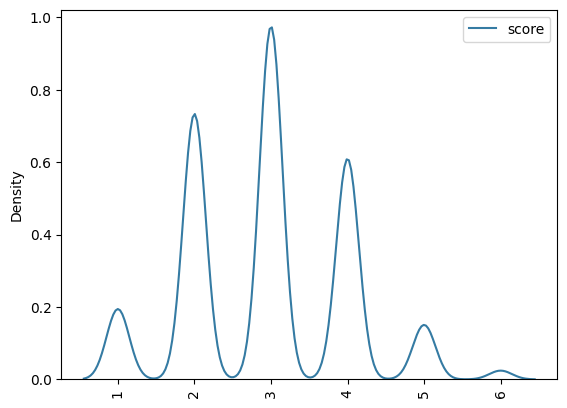

In [33]:
sns.kdeplot(data=combined,palette='mako');
plt.xticks(rotation=90);
plt.show()

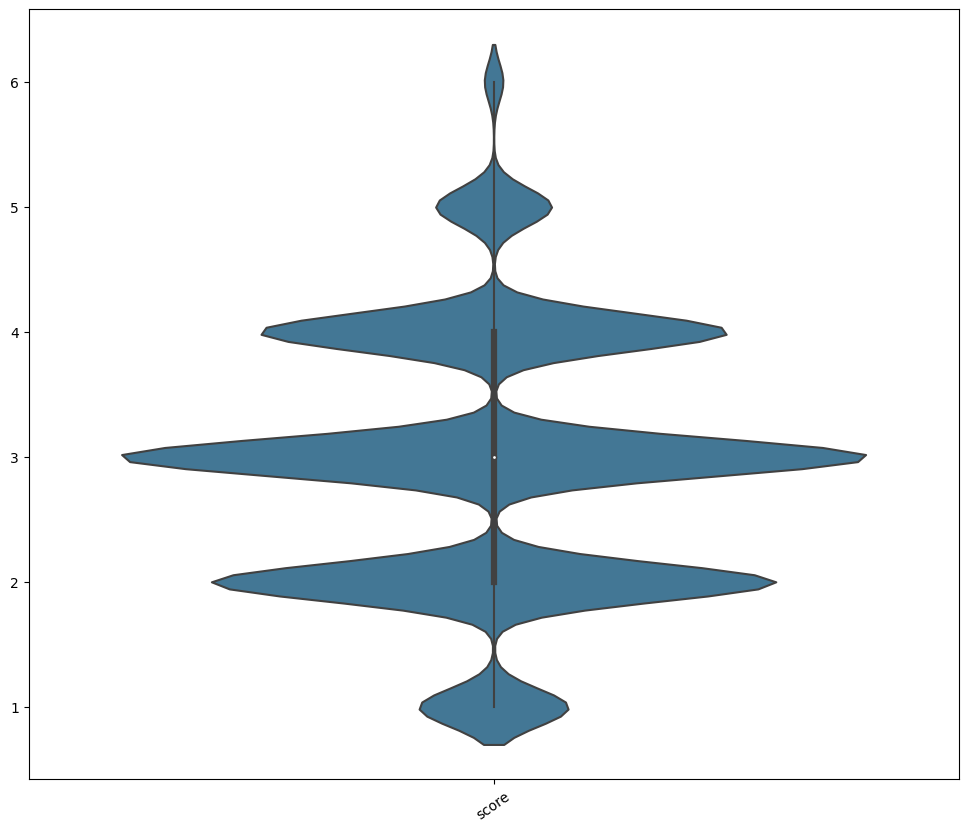

In [35]:
plt.figure(figsize=(12,10))
sns.violinplot(data=combined,palette='mako');
plt.xticks(rotation=35);
plt.show()

In [36]:
combined.head()

,essay_id,full_text,score
0,000d118,Many people have car where they live. The thin...,3.0
1,000fe60,I am a scientist at NASA that is discussing th...,3.0
2,001ab80,People always wish they had the same technolog...,4.0
3,001bdc0,"We all heard about Venus, the planet without a...",4.0
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3.0


In [37]:
import plotly.express as px
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm

In [38]:
import warnings
warnings.filterwarnings('ignore')

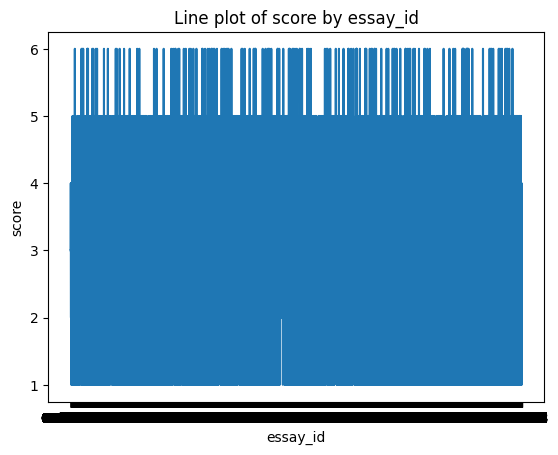

In [40]:
sns.lineplot(x='essay_id', y='score', data=combined)
plt.title("Line plot of score by essay_id")
plt.show()  

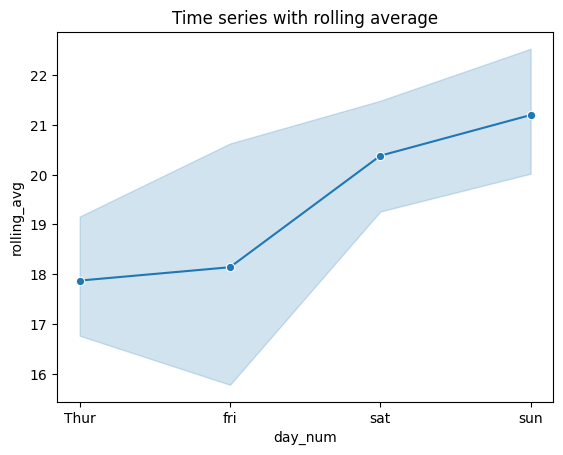

In [44]:
df_tips = sns.load_dataset("tips")
df_tips['day_num'] = df_tips['day'].astype('category').cat.codes

df_tips['rolling_avg'] = df_tips['total_bill'].rolling(window=3).mean()

sns.lineplot(x='day_num', y='rolling_avg', data=df_tips, marker='o')
plt.xticks(ticks=[0,1,2,3], labels=['Thur','fri','sat','sun'])
plt.title("Time series with rolling average")
plt.show()